In [1]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready


In [5]:
os.listdir()

['.config', 'yaleemmlc_admissionprediction_triage.csv', 'drive', 'sample_data']

In [14]:
df = pd.read_csv("yaleemmlc_admissionprediction_triage.csv", index_col=0)

print(df.shape)
df.head()


(55121, 225)


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
print("Total columns:", df.shape[1], "\n")

structured = [c for c in df.columns if not c.startswith("cc_")]
cc_flags   = [c for c in df.columns if c.startswith("cc_")]

print(f"Structured columns ({len(structured)}):")
for c in structured:
    print("   ", c)
print(f"\nChief-complaint flags (cc_*): {len(cc_flags)}  ->  grouped by body system in section 5")

Total columns: 225 

Structured columns (25):
    dep_name
    esi
    age
    gender
    ethnicity
    race
    lang
    religion
    maritalstatus
    employstatus
    insurance_status
    disposition
    arrivalmode
    arrivalmonth
    arrivalday
    arrivalhour_bin
    previousdispo
    triage_vital_hr
    triage_vital_sbp
    triage_vital_dbp
    triage_vital_rr
    triage_vital_o2
    triage_vital_o2_device
    triage_vital_temp
    triage_glucose

Chief-complaint flags (cc_*): 200  ->  grouped by body system in section 5


In [21]:
import numpy as np
import pandas as pd

TARGET = "esi"

# vitals + schema (you already have these in notebook, but repeat if needed)
VITALS = ["triage_vital_hr","triage_vital_sbp","triage_vital_dbp","triage_vital_rr",
          "triage_vital_o2","triage_vital_temp","triage_glucose"]

def classify_columns(df):
    chief_complaints = [c for c in df.columns if c.startswith("cc_")]

    return {
        "vitals": VITALS,
        "chief_complaints": chief_complaints
    }

def clean_triage(d):
    d = d.copy()

    # numeric conversion
    for c in VITALS + ["age"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    # fill vitals
    for c in VITALS:
        if c in d.columns:
            d[c] = d[c].fillna(d[c].median())

    return d

df = clean_triage(df)
fam = classify_columns(df)

print("Cleaned shape:", df.shape)

Cleaned shape: (55121, 225)


In [25]:
# Exercise 2 — is vitals missingness related to acuity?
# Compare ESI for rows missing triage_vital_o2 vs not.
n_missing = df["triage_vital_o2"].isna().sum()
print(f"Rows missing triage_vital_o2: {n_missing} of {len(df):,}")

if n_missing > 0:
    esi_missing = df.loc[df["triage_vital_o2"].isna(), TARGET]
    esi_present = df.loc[df["triage_vital_o2"].notna(), TARGET]
    print("\nMean ESI when o2 missing:", round(esi_missing.mean(), 2))
    print("Mean ESI when o2 present:", round(esi_present.mean(), 2))
else:
    print("\nThis extract has ZERO missing triage_vital_o2 values, so the comparison")
    print("cannot be run on this dataset — that absence is itself a finding worth a line")
    print("in the memo (see the issues table: 'Missing structured values — none found').")

    # Exercise 3 — how many cc_ columns are effectively constant (<0.5% prevalence)?
cc_prevalence = (df[fam["chief_complaints"]].mean() * 100).sort_values()
n_sparse = (cc_prevalence < 0.5).sum()
print(f"{n_sparse} of {len(cc_prevalence)} cc_ columns ({n_sparse/len(cc_prevalence)*100:.1f}%) "
      f"have <0.5% prevalence.")
print("\nSparsest 10 chief complaints (rarest first):")
print(cc_prevalence.head(10).round(3))

Rows missing triage_vital_o2: 0 of 55,121

This extract has ZERO missing triage_vital_o2 values, so the comparison
cannot be run on this dataset — that absence is itself a finding worth a line
in the memo (see the issues table: 'Missing structured values — none found').
149 of 200 cc_ columns (74.5%) have <0.5% prevalence.

Sparsest 10 chief complaints (rarest first):
cc_cardiacarrest        0.000
cc_fulltrauma           0.007
cc_ingestion            0.018
cc_bodyfluidexposure    0.018
cc_exposuretostd        0.024
cc_hyperglycemia        0.025
cc_foreignbodyineye     0.025
cc_trauma               0.025
cc_modifiedtrauma       0.029
cc_tickremoval          0.031
dtype: float64


· Plot 1 — Missingness before cleaning (structured)

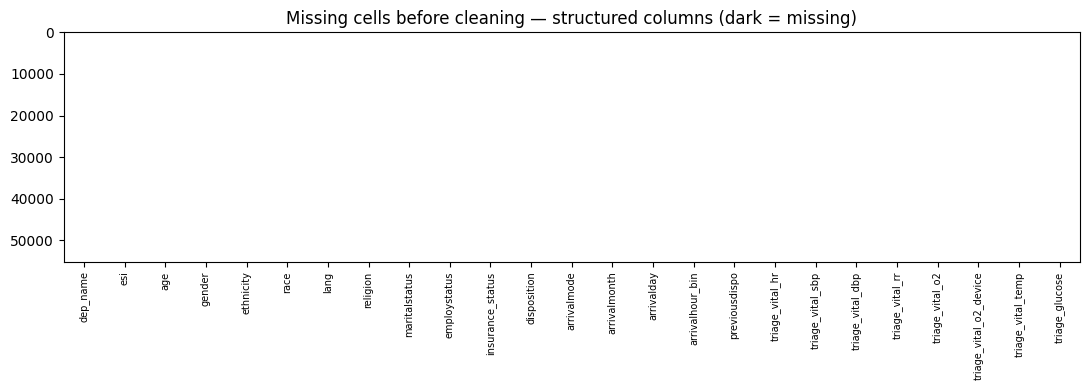

In [35]:
import matplotlib.pyplot as plt
import os

os.makedirs("figs", exist_ok=True)

src = df   # <-- safest fix

structured = [c for c in src.columns if not c.startswith("cc_")]

fig, ax = plt.subplots(figsize=(11,4))
ax.imshow(src[structured].isna().values, aspect="auto", cmap="gray_r")

ax.set_xticks(range(len(structured)))
ax.set_xticklabels(structured, rotation=90, fontsize=7)

ax.set_title("Missing cells before cleaning — structured columns (dark = missing)")

plt.tight_layout()
plt.savefig("figs/01_missingness.png", dpi=110)
plt.show()

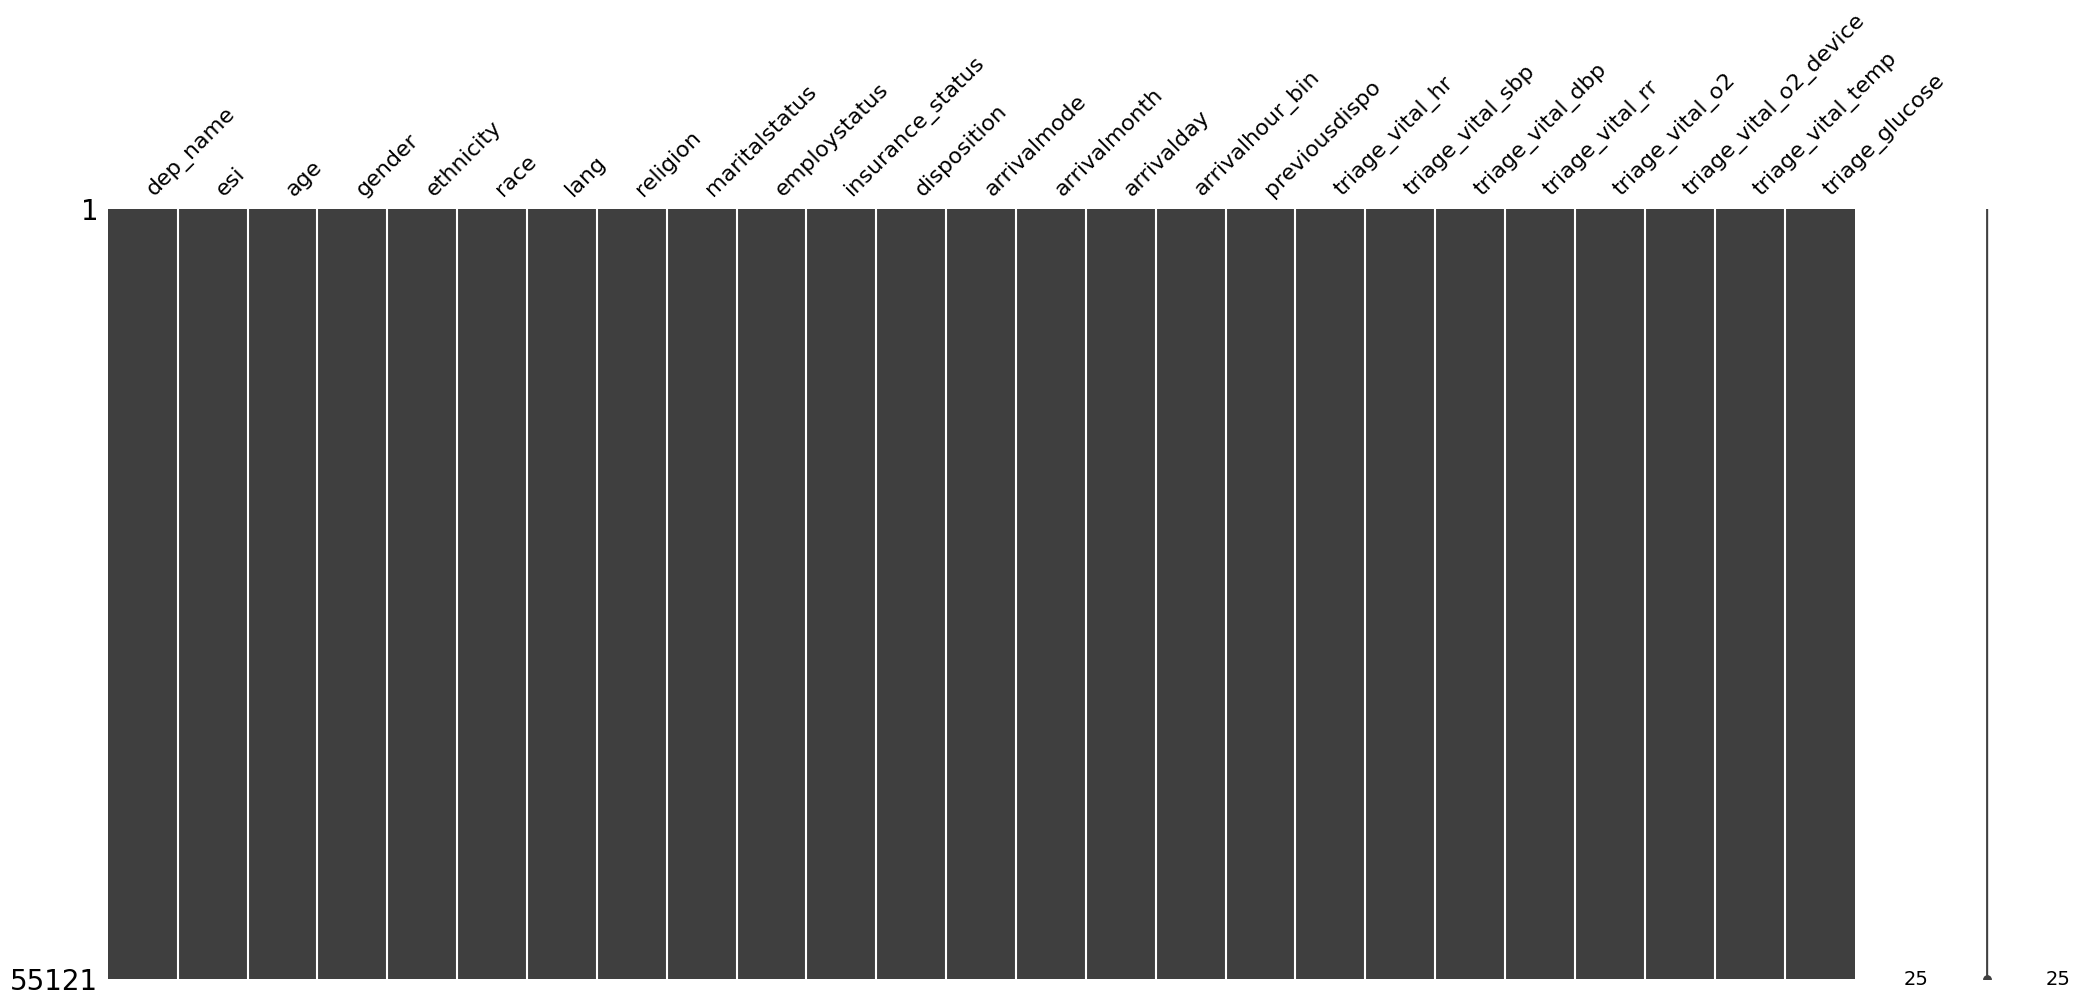

In [36]:
try:
    import missingno as msno              # Colab: !pip install missingno -q
    msno.matrix(df[structured]); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells — structured columns (dark = missing)"); plt.tight_layout(); plt.show()

 · Plot 2 — ESI class balance & age

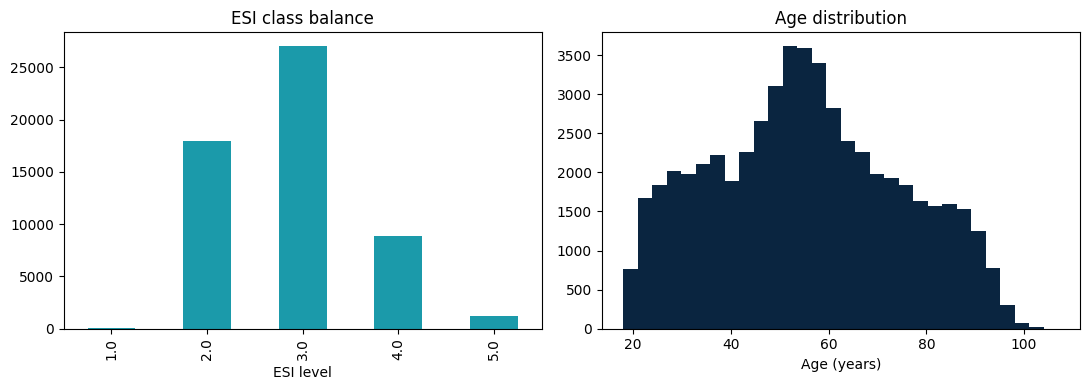

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))

esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0], color="#1B9AAA")
ax[0].set_title("ESI class balance"); ax[0].set_xlabel("ESI level")

ax[1].hist(df["age"], bins=30, color="#0A2540")
ax[1].set_title("Age distribution"); ax[1].set_xlabel("Age (years)")

plt.tight_layout(); plt.savefig("figs/02_esi_age.png", dpi=110); plt.show()

4 · Plot 3 — Race & ethnicity (required, and a fairness lens)

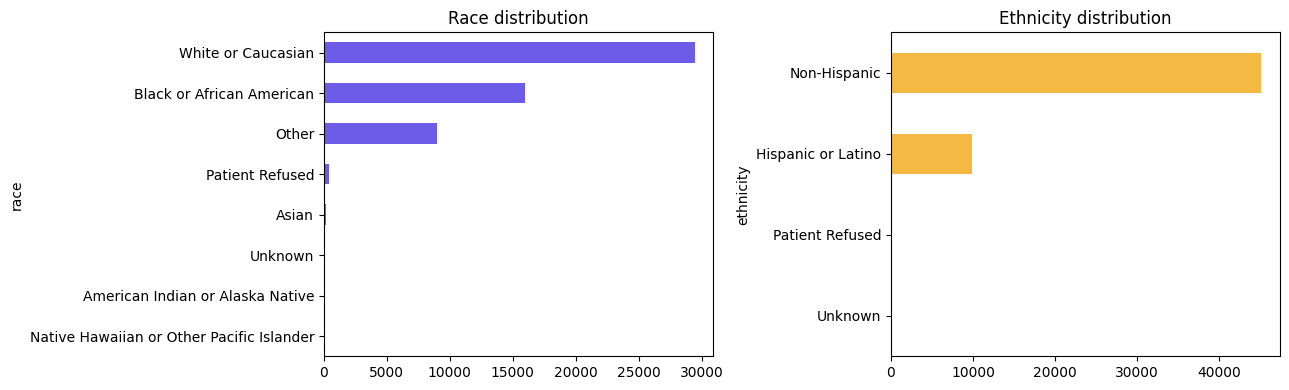

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))

df["race"].value_counts().plot.barh(ax=ax[0], color="#6C5CE7")
ax[0].set_title("Race distribution"); ax[0].invert_yaxis()

df["ethnicity"].value_counts().plot.barh(ax=ax[1], color="#F4B942")
ax[1].set_title("Ethnicity distribution"); ax[1].invert_yaxis()

plt.tight_layout(); plt.savefig("figs/03_demographics.png", dpi=110); plt.show()

## 5 · Plot 4 — Top chief complaints (required)

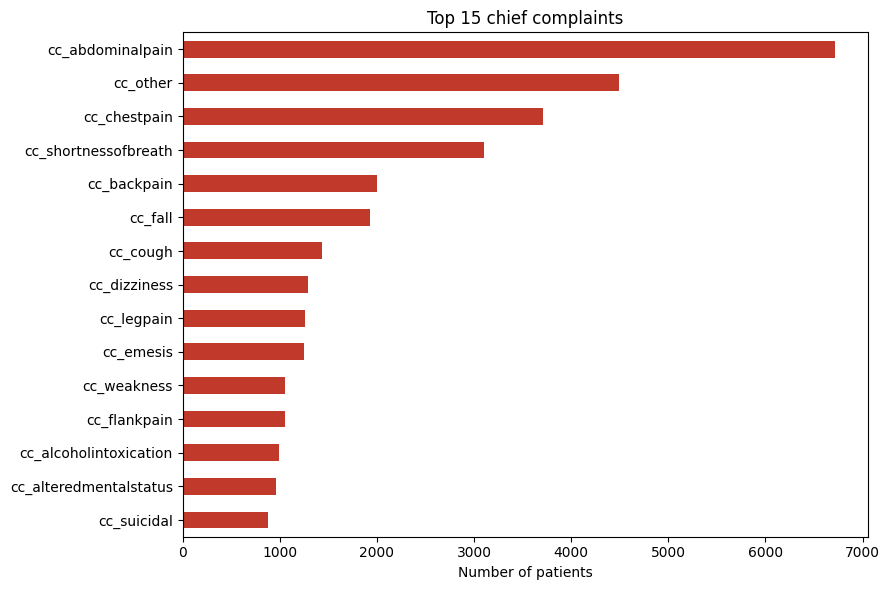

In [29]:
top15 = df[fam["chief_complaints"]].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9,6))
top15[::-1].plot.barh(ax=ax, color="#C0392B")
ax.set_title("Top 15 chief complaints"); ax.set_xlabel("Number of patients")

plt.tight_layout(); plt.savefig("figs/04_chief_complaints.png", dpi=110); plt.show()

## 6 · Plot 5 — Do vitals separate the ESI classes?

In [ ]:
vitals_to_plot = ["triage_vital_hr","triage_vital_sbp","triage_vital_rr",
                  "triage_vital_o2","triage_vital_temp","triage_glucose"]
esi_levels = sorted(df[TARGET].unique())
fig, axes = plt.subplots(2, 3, figsize=(13,7))
for panel, col in zip(axes.ravel(), vitals_to_plot):
    groups = [df.loc[df[TARGET] == level, col] for level in esi_levels]
    panel.boxplot(groups, tick_labels=[int(l) for l in esi_levels])
    panel.set_title(col, fontsize=9); panel.set_xlabel("ESI")
plt.tight_layout(); plt.savefig("figs/05_vitals_by_esi.png", dpi=110); plt.show()

## 7 · Plot 6 — Correlation (vitals + ESI) and complaint↔acuity

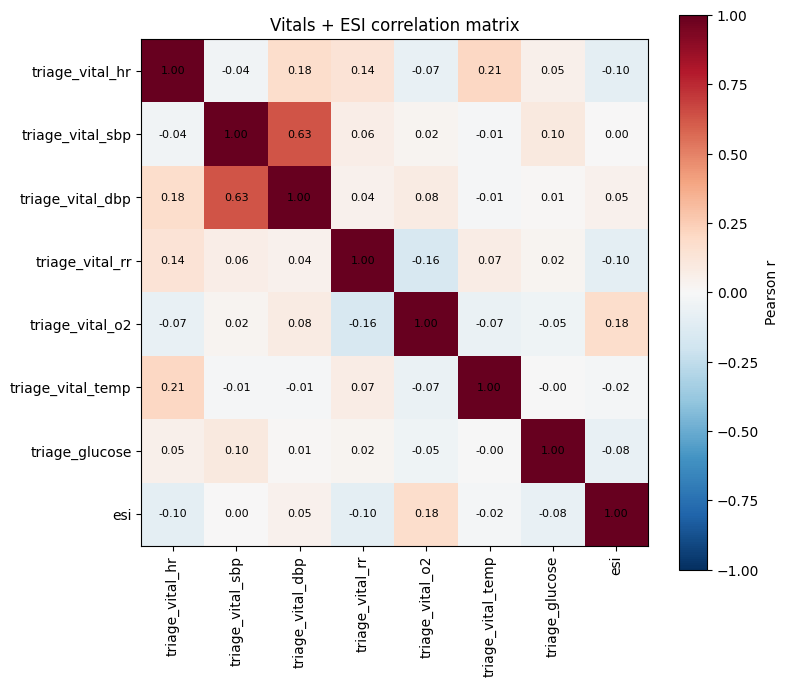

In [28]:
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Vitals + ESI correlation matrix")

plt.tight_layout(); plt.savefig("figs/06_correlation.png", dpi=110); plt.show()

triage_vital_o2      0.178
triage_vital_rr      0.095
triage_vital_hr      0.095
triage_glucose       0.078
triage_vital_dbp     0.046
triage_vital_temp    0.022
triage_vital_sbp     0.001
dtype: float64
Best separator:  triage_vital_o2  (|r| = 0.178)
Worst separator: triage_vital_sbp  (|r| = 0.001)
esi           1.0   2.0    3.0   4.0  5.0
cc_chestpain                             
0.0           0.1  30.6   49.7  17.2  2.4
1.0           0.1  59.1   39.7   1.0  0.0
2.0           0.0   0.0  100.0   0.0  0.0


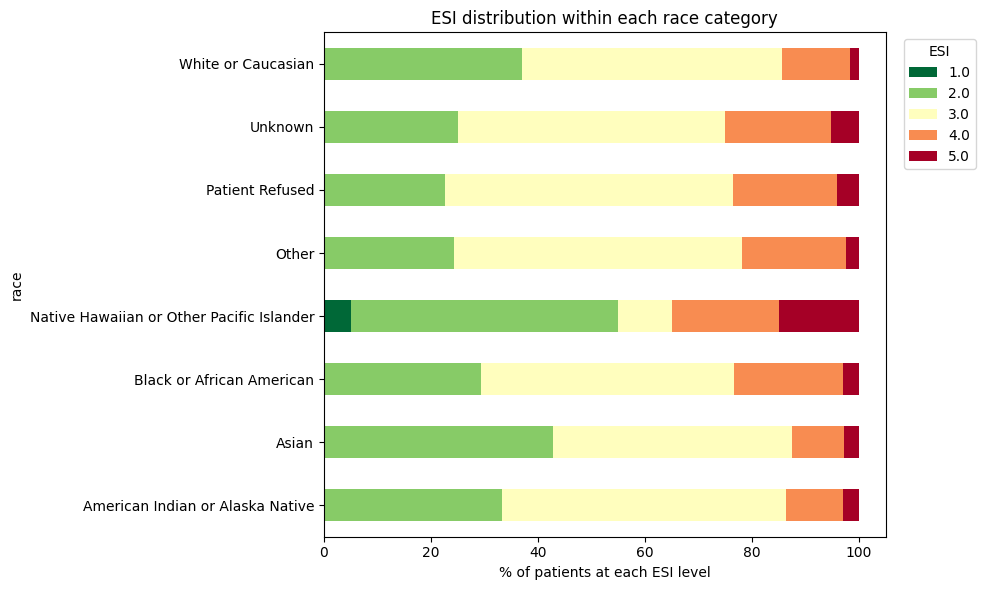

In [27]:
# Ex2 — best/worst separating vital
sep = df[fam["vitals"]].corrwith(df[TARGET]).abs().sort_values(ascending=False)
print(sep.round(3))
print(f"Best separator:  {sep.index[0]}  (|r| = {sep.iloc[0]:.3f})")
print(f"Worst separator: {sep.index[-1]}  (|r| = {sep.iloc[-1]:.3f})")

# Ex3 — cc_chestpain vs ESI
ct = pd.crosstab(df["cc_chestpain"], df[TARGET], normalize="index") * 100
print(ct.round(1))

# Ex4 — equity: ESI distribution within race
esi_by_race = pd.crosstab(df["race"], df[TARGET], normalize="index") * 100
fig, ax = plt.subplots(figsize=(10,6))
esi_by_race.plot.barh(stacked=True, ax=ax, colormap="RdYlGn_r")
ax.set_xlabel("% of patients at each ESI level"); ax.set_title("ESI distribution within each race category")
ax.legend(title="ESI", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.savefig("figs/07_equity_esi_by_race.png", dpi=110); plt.show()